In [190]:
import pandas as pd

In [191]:
cd = pd.read_csv("olist_customers_dataset.csv") 
gd=pd.read_csv("olist_geolocation_dataset.csv")
ot=pd.read_csv("olist_order_items_dataset.csv")
od=pd.read_csv("olist_orders_dataset.csv")
pyd=pd.read_csv("olist_order_payments_dataset.csv")
ord=pd.read_csv("olist_order_reviews_dataset.csv")
odd=pd.read_csv("olist_orders_dataset.csv")
prd=pd.read_csv("olist_products_dataset.csv")
osd=pd.read_csv("olist_sellers_dataset.csv")
pcn=pd.read_csv("product_category_name_translation.csv")

📊 Business Request: Understand Customer Spending Behavior

In [192]:
ot['revenue'] = ot['price'] + ot['freight_value']
ot

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,revenue
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,72.19
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,259.83
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,216.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,218.04
...,...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,343.40
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,386.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95,116.85
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72,64.71


In [193]:
# Average order value
order_value = ot.groupby('order_id')['revenue'].sum()
average_order_value = order_value.mean()
print(round(average_order_value, 2))

160.58


In [194]:
# Typical order value
typical_order_value = order_value.median()
print(round(typical_order_value, 2))

105.29


high_value_customers


In [195]:
order_value.reset_index()

,order_id,revenue
0,00010242fe8c5a6d1ba2dd792cb16214,72.19
1,00018f77f2f0320c557190d7a144bdd3,259.83
2,000229ec398224ef6ca0657da4fc703e,216.87
3,00024acbcdf0a6daa1e931b038114c75,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04
...,...,...
98661,fffc94f6ce00a00581880bf54a75a037,343.40
98662,fffcd46ef2263f404302a634eb57f7eb,386.53
98663,fffce4705a9662cd70adb13d4a31832d,116.85
98664,fffe18544ffabc95dfada21779c9644f,64.71


In [196]:
customer_order=od[['order_id','customer_id']].merge(ot,how='left',on='order_id')

In [197]:
customer_order

,order_id,customer_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,revenue
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,28.62
...,...,...,...,...,...,...,...,...,...
113420,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,1.0,f1d4ce8c6dd66c47bbaa8c6781c2a923,1f9ab4708f3056ede07124aad39a2554,2018-02-12 13:10:37,174.90,20.10,195.00
113421,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,1.0,b80910977a37536adeddd63663f916ad,d50d79cb34e38265a8649c383dcffd48,2017-09-05 15:04:16,205.99,65.02,271.01
113422,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,1.0,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,2018-01-12 21:36:21,179.99,40.59,220.58
113423,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,2.0,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,2018-01-12 21:36:21,179.99,40.59,220.58


In [198]:
high_value_customers = (
    customer_order
    .groupby(['order_id', 'customer_id'])
    .agg(
        total_revenue=('revenue', 'sum'),
        total_orders=('order_id', 'count'),
        average_order_value=('revenue', 'mean')
    )
    .reset_index()
)

In [199]:
high_value_customers.sort_values(by='total_revenue', ascending=False).head(10)

,order_id,customer_id,total_revenue,total_orders,average_order_value
1471,03caa2c082116e1d31e67e9ae3700499,1617b1357756262bfa56ab541c47bc16,13664.08,8,1708.01
44830,736e1922ae60d0d6a89247b851902527,ec5b2ba62e574342386871631fafd3fc,7274.88,4,1818.72
3156,0812eb902a67711a1cb742b3cdaa65ae,c6e2731c5b391845f6800c97401a43a9,6929.31,1,6929.31
99072,fefacc66af859508bf1a7934eab1e97f,f48d464a0baaea338cb25f816991ab1f,6922.21,1,6922.21
95187,f5136e38d1a14a4dbd87dff67da82701,3fd6777bbce08a352fddd04e4a7cc8f6,6726.66,1,6726.66
17255,2cc9089445046817a7539d90805e6e5a,05455dfa7cd02f13d132aa7a6a9729c6,6081.54,6,1013.59
65576,a96610ab360d42a2e5335a3998b4718a,df55c14d1476a9a3467f131269c2477f,4950.34,1,4950.34
70098,b4c4b76c642808cbe472a32b86cddc95,e0a2412720e9ea4f26c1ac985f6a7358,4809.44,2,2404.72
9941,199af31afc78c699f0dbf71fb178d4d4,24bbf5fd2f2e1b359ee7de94defc4a15,4764.34,1,4764.34
54793,8dbc85d1447242f3b127dda390d56e19,3d979689f636322c62418b6346b1c6d2,4681.78,1,4681.78


## Is spending consistent?

In [200]:
#Mean vs Median
if average_order_value < typical_order_value:
    print("Spending is fairly consistent")
elif average_order_value > typical_order_value:
    print("A few expensive orders are pulling the average up")
else:
    print("Spending is fairly consistent")

A few expensive orders are pulling the average up


In [201]:
#Standard Deviation
#Do customers have similar average spending habits?
standard_deviation = high_value_customers['average_order_value'].std()
standard_deviation

198.22662837407265

In [202]:
#Is customer spending consistent per order?
customer_standard_deviation = high_value_customers['total_revenue'].std()
customer_standard_deviation 

220.05880401249078

CV	Interpretation
< 25%	Very consistent
25–50%	Fairly consistent
50–100%	High variation
> 100%	Very high variation / highly inconsistent

In [203]:
#Coefficient of Variation (CV)
print((standard_deviation/average_order_value)*100)

123.44597338037697


In [204]:
#Coefficient of Variation (CV)
print((standard_deviation/average_order_value)*100)

123.44597338037697


Conclution:
Customer spending is highly inconsistent. The coefficient of variation is 123%, meaning the variation in order values exceeds the average order value. This suggests that while many customers place relatively small orders, a smaller group of customers places much larger orders, resulting in a wide spread of spending.

📊 Business Request: Identify Unusual Transactions

In [205]:
import matplotlib.pyplot as plt
import seaborn as sns

In [206]:
high_value_customers

,order_id,customer_id,total_revenue,total_orders,average_order_value
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,72.19,1,72.19
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,259.83,1,259.83
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,216.87,1,216.87
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,25.78,1,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,218.04,1,218.04
...,...,...,...,...,...
99436,fffc94f6ce00a00581880bf54a75a037,b51593916b4b8e0d6f66f2ae24f2673d,343.40,1,343.40
99437,fffcd46ef2263f404302a634eb57f7eb,84c5d4fbaf120aae381fad077416eaa0,386.53,1,386.53
99438,fffce4705a9662cd70adb13d4a31832d,29309aa813182aaddc9b259e31b870e6,116.85,1,116.85
99439,fffe18544ffabc95dfada21779c9644f,b5e6afd5a41800fdf401e0272ca74655,64.71,1,64.71


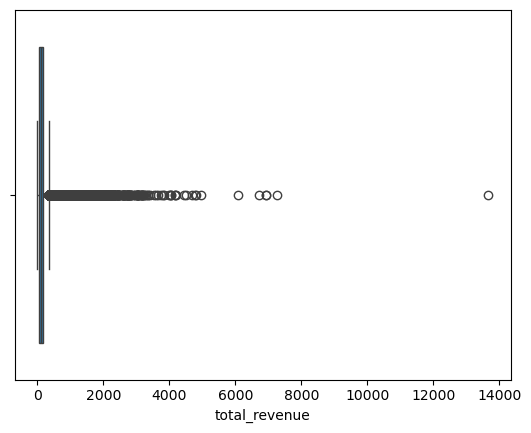

In [207]:
sns.boxplot(x=high_value_customers['total_revenue'])
plt.show()

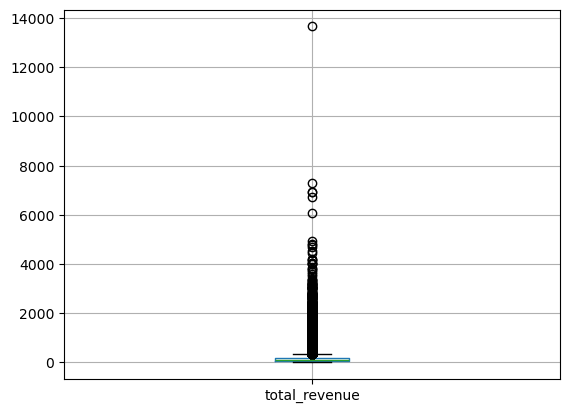

In [208]:
high_value_customers.boxplot(column='total_revenue')
plt.show()

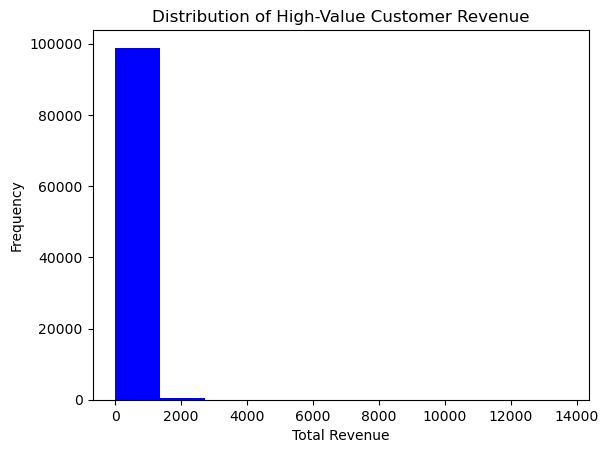

In [209]:
plt.hist(high_value_customers['total_revenue'],color='blue')
plt.xlabel('Total Revenue')
plt.ylabel('Frequency')
plt.title('Distribution of High-Value Customer Revenue')
plt.show()

Histogram conlusiton: The first bar (left side) is extremely tall, while almost all other bars are very small.

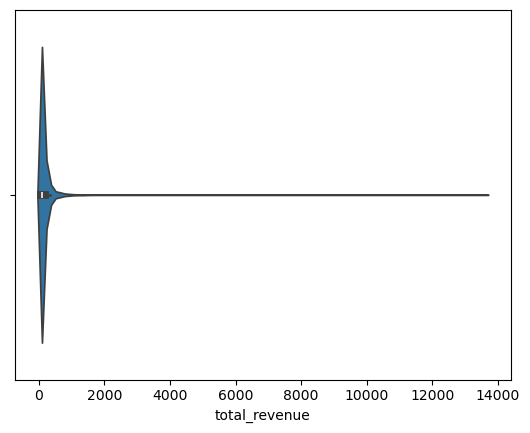

In [210]:
sns.violinplot(x=high_value_customers['total_revenue'])
plt.show()

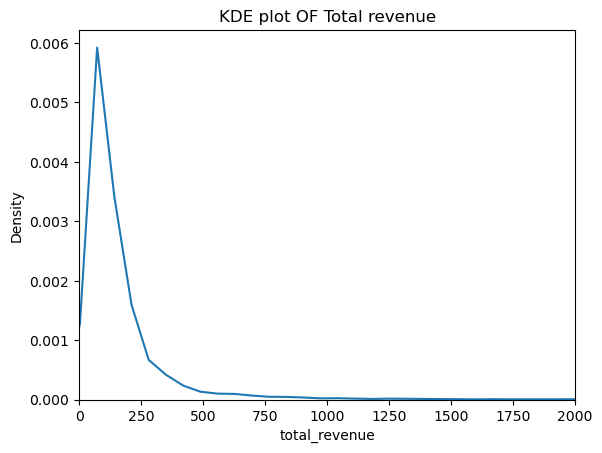

In [211]:
sns.kdeplot(data=high_value_customers['total_revenue'])
plt.title("KDE plot OF Total revenue")
plt.xlim(0,2000)
plt.show()


Extremely right-skewed

### 📊 Business Request: Identify Relationships Between Variables

In [212]:
Questions
-Does higher payment value lead to higher review scores?
-Does longer delivery time reduce customer ratings?
-Does freight cost increase with product weight?

NameError: name 'Questions' is not defined

In [216]:
ot

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,revenue
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,72.19
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,259.83
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,216.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,218.04
...,...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,343.40
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,386.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95,116.85
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72,64.71


In [228]:
review_data = (
    ot.groupby(['order_id', 'product_id'])
      .agg(total=('price', 'sum'))
      .reset_index()
      .merge(prd[['product_id', 'product_category_name']], on='product_id', how='left')
)

In [232]:
review_data=review_data.merge(ord[['order_id', 'review_score']], on='order_id', how='left')

In [233]:
review_data

,order_id,product_id,total,product_category_name,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,4244733e06e7ecb4970a6e2683c13e61,58.90,cool_stuff,5.0
1,00018f77f2f0320c557190d7a144bdd3,e5f2d52b802189ee658865ca93d83a8f,239.90,pet_shop,4.0
2,000229ec398224ef6ca0657da4fc703e,c777355d18b72b67abbeef9df44fd0fd,199.00,moveis_decoracao,5.0
3,00024acbcdf0a6daa1e931b038114c75,7634da152a4610f1595efa32f14722fc,12.99,perfumaria,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,ac6c3623068f30de03045865e4e10089,199.90,ferramentas_jardim,5.0
...,...,...,...,...,...
103022,fffc94f6ce00a00581880bf54a75a037,4aa6014eceb682077f9dc4bffebc05b0,299.99,utilidades_domesticas,5.0
103023,fffcd46ef2263f404302a634eb57f7eb,32e07fd915822b0765e448c4dd74c828,350.00,informatica_acessorios,5.0
103024,fffce4705a9662cd70adb13d4a31832d,72a30483855e2eafc67aee5dc2560482,99.90,esporte_lazer,5.0
103025,fffe18544ffabc95dfada21779c9644f,9c422a519119dcad7575db5af1ba540e,55.99,informatica_acessorios,5.0


In [243]:
pivot=pd.pivot_table(
    review_data,
    index='product_category_name',
    columns='review_score',
    values='order_id',
    aggfunc='count',
    fill_value=0
)

In [267]:
new = (
    review_data.groupby("product_category_name")
    .agg(
        review_count=("review_score", "count"),
        average_review=("review_score", "mean"),
        total_sales=("total", "sum"),
        average_price=("total", "mean")
    )
    .reset_index()
)

In [271]:
new

,product_category_name,review_count,average_review,total_sales,average_price
0,agro_industria_e_comercio,183,4.027322,72530.47,396.341366
1,alimentos,448,4.270089,29393.41,64.886115
2,alimentos_bebidas,235,4.395745,15270.47,64.705381
3,artes,200,4.025000,24202.64,119.815050
4,artes_e_artesanato,24,4.125000,1814.01,75.583750
...,...,...,...,...,...
68,sinalizacao_e_seguranca,141,4.092199,21509.23,150.414196
69,tablets_impressao_imagem,77,4.155844,7528.41,95.296329
70,telefonia,4259,3.984269,323839.40,75.451864
71,telefonia_fixa,215,3.902326,59622.99,273.499954


In [277]:
corr=new.corr(numeric_only=True)

In [278]:
corr



,review_count,average_review,total_sales,average_price
review_count,1.000000,0.032421,0.957486,-0.106046
average_review,0.032421,1.000000,0.034783,-0.019335
total_sales,0.957486,0.034783,1.000000,0.018028
average_price,-0.106046,-0.019335,0.018028,1.000000


<Axes: >

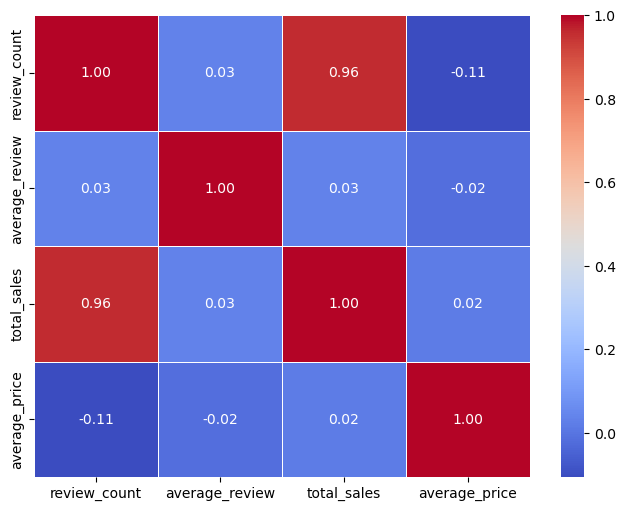

In [286]:
plt.figure(figsize=(8,6))
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt='.2f',linewidths=0.5)

'''
Correlation	Meaning
+1	Perfect positive relationship
0.7 to 0.9	Strong positive
0.3 to 0.7	Moderate positive
0	No relationship
-0.3 to -0.7	Moderate negative
-0.7 to -1	Strong negative
'''

### high value data frame

In [289]:
corr=high_value_customers.corr(numeric_only=True)

In [290]:
corr

,total_revenue,total_orders,average_order_value
total_revenue,1.000000,0.190205,0.924475
total_orders,0.190205,1.000000,-0.058466
average_order_value,0.924475,-0.058466,1.000000


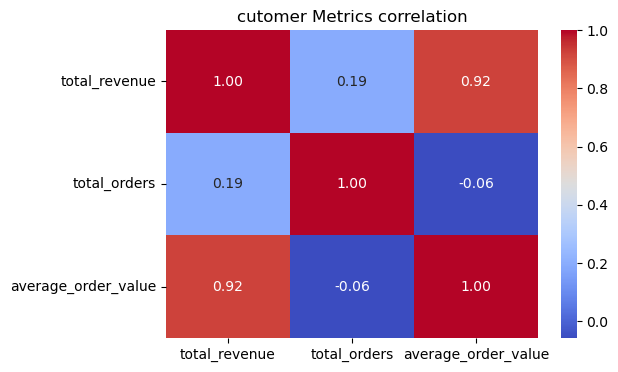

In [297]:
plt.figure(figsize=(6,4))
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt='.2f')
plt.title("cutomer Metrics correlation")
plt.show()